<a href="https://colab.research.google.com/github/nikhil-xyz/ipp/blob/main/Insurance_Premium_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

reading data

In [9]:
data = pd.read_csv('/content/insurance.csv')

In [10]:
data.shape

(1338, 7)

In [11]:
data.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [12]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

importing depemdencies

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

assigning labels to feature values

In [14]:
le_gender = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()
le_gender.fit(data.sex)
le_smoker.fit(data.smoker)
le_region.fit(data.region)
data['sex'] = le_gender.transform(data.sex)
data['smoker'] = le_smoker.transform(data.smoker)
data['region'] = le_region.transform(data.region)

In [15]:
le_name_mapping = dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))
print(le_name_mapping)

{'female': 0, 'male': 1}


In [16]:
le_gender.transform(['male'])[0]

1

In [19]:
import pickle

In [20]:
pickle.dump(le_gender, open('le_gender.pkl', 'wb'))
pickle.dump(le_smoker, open('le_smoker.pkl', 'wb'))
pickle.dump(le_region, open('le_region.pkl', 'wb'))

In [21]:
data.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,0,27.9,0,1,3,16884.92
1,18,1,33.8,1,0,2,1725.55
2,28,1,33.0,3,0,2,4449.46
3,33,1,22.7,0,0,1,21984.47
4,32,1,28.9,0,0,1,3866.86


deciding input and output features

In [22]:
X = data.iloc[:, :6]
y = data.iloc[:, -1]

In [23]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.9,0,1,3
1,18,1,33.8,1,0,2
2,28,1,33.0,3,0,2
3,33,1,22.7,0,0,1
4,32,1,28.9,0,0,1


In [24]:
y.head()

0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: expenses, dtype: float64

spliting train and test data

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [26]:
X_train.shape

(1070, 6)

In [27]:
y_train.shape

(1070,)

In [28]:
y_train

545     23807.24
1190     5327.40
1121     8347.16
865      6600.36
476     35147.53
          ...   
191      4883.87
1015    12124.99
56      13607.37
1316     1731.68
104      5003.85
Name: expenses, Length: 1070, dtype: float64

In [29]:
X_train

,age,sex,bmi,children,smoker,region
545,49,1,25.8,2,1,1
1190,31,0,32.8,2,0,1
1121,46,1,38.2,2,0,2
865,40,1,29.9,2,0,3
476,24,1,28.5,0,1,0
...,...,...,...,...,...,...
191,36,0,26.2,0,0,3
1015,59,1,25.5,0,0,1
56,58,0,31.8,2,0,0
1316,19,0,20.6,0,0,3


In [30]:
X_test.shape

(268, 6)

In [31]:
y_test.shape

(268,)

with Random Forrest Regressor

In [32]:
rf = RandomForestRegressor(n_estimators=150)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=150)

In [33]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'expenses')

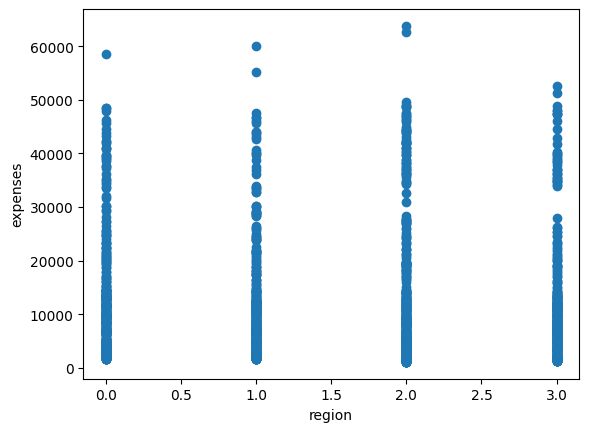

In [34]:
plt.scatter(data['region'], data['expenses'])
plt.xlabel('region')
plt.ylabel('expenses')

In [35]:
data[data['expenses'] > 55000]

,age,sex,bmi,children,smoker,region,expenses
543,54,0,47.4,0,1,2,63770.43
577,31,0,38.1,1,1,0,58571.07
819,33,0,35.5,0,1,1,55135.40
1230,52,1,34.5,3,1,1,60021.40
1300,45,1,30.4,0,1,2,62592.87


In [36]:
# indexes = data[data['expenses'] > 55000].index
# data.drop(indexes, inplace=True)

Text(0, 0.5, 'expenses')

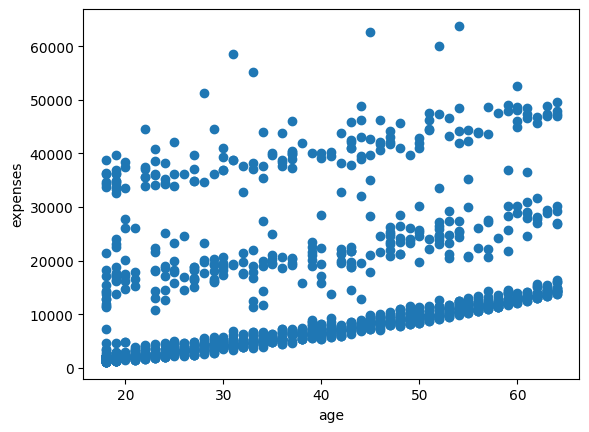

In [37]:
plt.scatter(data['age'], data['expenses'])
plt.xlabel('age')
plt.ylabel('expenses')

Text(0, 0.5, 'expenses')

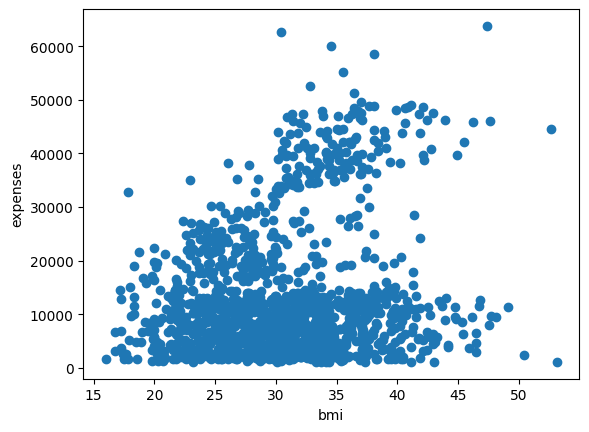

In [38]:
plt.scatter(data['bmi'], data['expenses'])
plt.xlabel('bmi')
plt.ylabel('expenses')

Text(0, 0.5, 'expenses')

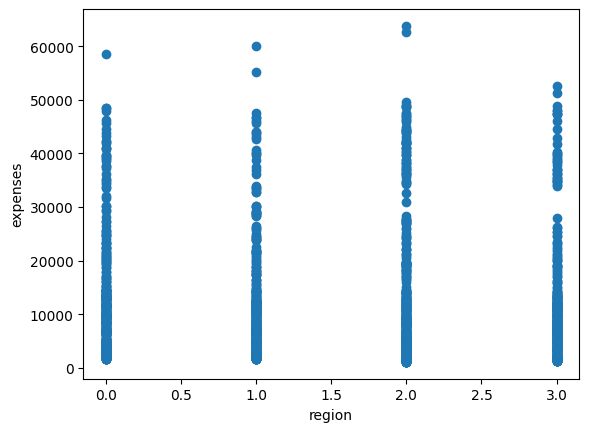

In [39]:
plt.scatter(data['region'], data['expenses'])
plt.xlabel('region')
plt.ylabel('expenses')

Text(0, 0.5, 'expenses')

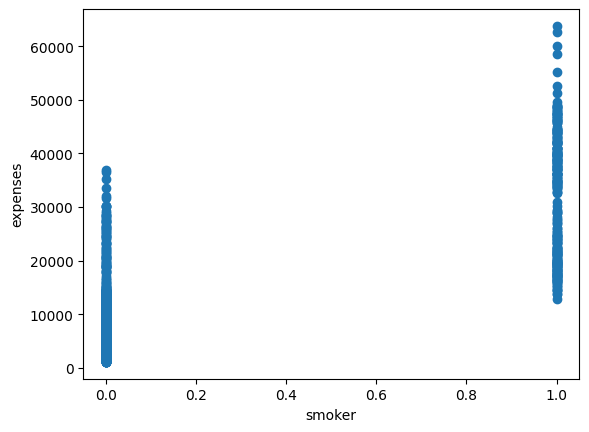

In [40]:
plt.scatter(data['smoker'], data['expenses'])
plt.xlabel('smoker')
plt.ylabel('expenses')

Text(0, 0.5, 'expenses')

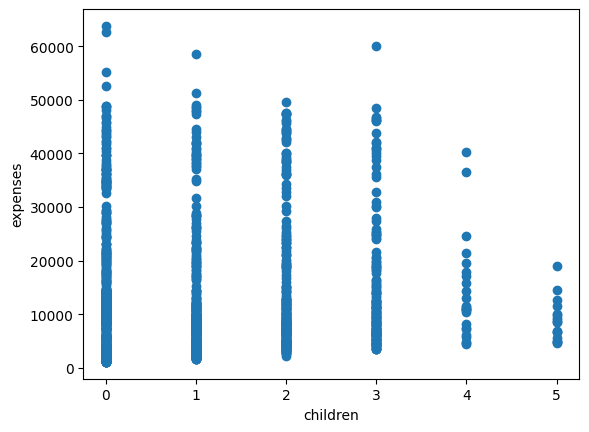

In [41]:
plt.scatter(data['children'], data['expenses'])
plt.xlabel('children')
plt.ylabel('expenses')

In [42]:
data[data['smoker']==1]

,age,sex,bmi,children,smoker,region,expenses
0,19,0,27.9,0,1,3,16884.92
11,62,0,26.3,0,1,2,27808.73
14,27,1,42.1,0,1,2,39611.76
19,30,1,35.3,0,1,3,36837.47
23,34,0,31.9,1,1,0,37701.88
...,...,...,...,...,...,...,...
1313,19,0,34.7,2,1,3,36397.58
1314,30,0,23.7,3,1,1,18765.88
1321,62,1,26.7,0,1,0,28101.33
1323,42,0,40.4,2,1,2,43896.38


In [43]:
sort = rf.feature_importances_.argsort()
fnm = list(data.columns.values.tolist())
fnm = fnm[:6]

checking contribution of input features in final output with Random Forest Regressor

Text(0.5, 0, 'Feature Importance')

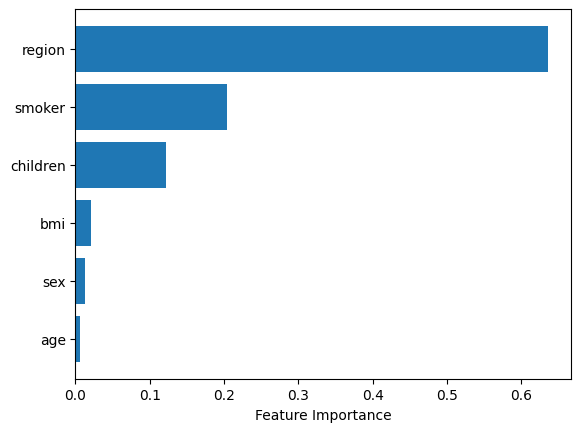

In [44]:
plt.barh(fnm, rf.feature_importances_[sort])
plt.xlabel("Feature Importance")

object of Gradient boosting regressor

In [45]:
gbr = GradientBoostingRegressor(n_estimators=150)
gbr.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=150)

feature importance with Gradient Boosting Regressor

Text(0.5, 0, 'Feature Importance')

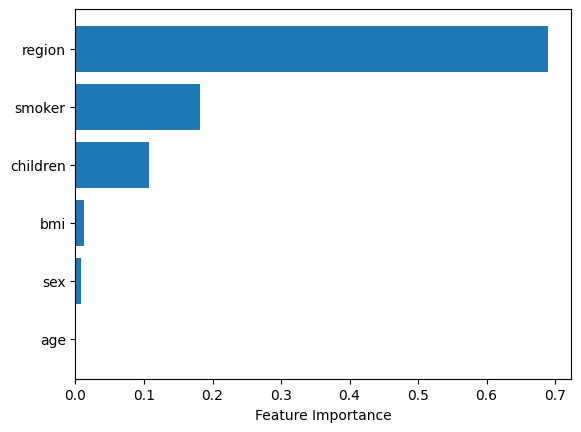

In [46]:
sort = gbr.feature_importances_.argsort()
plt.barh(fnm, gbr.feature_importances_[sort])
plt.xlabel("Feature Importance")

selecting features with high importance, removing features with low importance

In [47]:
X = data.iloc[:, 3:6]
y = data.iloc[:, -1]

In [48]:
X.head()

,children,smoker,region
0,0,1,3
1,1,0,2
2,3,0,2
3,0,0,1
4,0,0,1


In [49]:
y.head()

0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: expenses, dtype: float64

spliting original data for training the model

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

In [51]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [52]:
gbc = GradientBoostingRegressor(n_estimators=150)

In [53]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=150)

In [54]:
y_pred = gbr.predict(X_test)
error = r2_score(y_test,y_pred)
print(error)

0.6416038397977193


Applying same process with all the input features

In [55]:
X = data.iloc[:, :6]
y = data.iloc[:, -1]
gbc = GradientBoostingRegressor(n_estimators=150)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
error = r2_score(y_test,y_pred)
print(error)

0.8794410838536213


In [56]:
gbr.predict([[19, 0, 27.9, 0, 1, 3]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


array([19587.31559065])

In [57]:
gbr.predict([[30,1,35.3,0,1,3]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


array([37821.14576702])

saving the model

In [58]:
import pickle
pickle.dump(gbr, open('model.pkl', 'wb'))

with multiple linear regression

In [59]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
error = r2_score(y_test,y_pred)
print(error)

0.7791046496020663
